<a href="https://colab.research.google.com/github/DudeUnoob/language-modeling/blob/main/makemore_pt2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Character-Level Language Model (MLP)

This notebook demonstrates a neural language model based on the MLP architecture described by Bengio et al. (2003). The goal is to predict the next character in a sequence given a fixed window of previous characters (context).

### Key Features:
*   **Word-to-Character Tokenization**: Converting names into training sequences.
*   **Embeddings**: Mapping characters into a continuous low-dimensional space.
*   **Bengio et al. Architecture**: Implementing hidden layers with optional 'direct' connections from embeddings to output logits.
*   **Optimization**: Using mini-batch gradient descent with learning rate scheduling.

In [3]:
import torch

import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [5]:
words = open("names.txt", "r").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

### 1. Data Loading
We start by loading a dataset of names. Each name serves as a sequence of characters for the model to learn.

In [6]:
len(words)

32033

In [7]:

chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}

### 2. Tokenization
We create a lookup table to map each character to a unique integer (stoi) and vice versa (itos). The special `.` character is used to denote the start and end of words.

In [8]:
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [9]:
# build the dataset

block_size = 5 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:

  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [10]:
# build the dataset
block_size = 5 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

  X = torch.tensor(X).to(device)
  Y = torch.tensor(Y).to(device)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 5]) torch.Size([182625])
torch.Size([22655, 5]) torch.Size([22655])
torch.Size([22866, 5]) torch.Size([22866])


### 3. Dataset Splitting
We split the data into **Training** (80%), **Validation** (10%), and **Test** (10%) sets to monitor for overfitting and evaluate performance on unseen data.

In [11]:
C = torch.randn((27, 2))


In [12]:
emb = C[X]
emb.shape

torch.Size([228146, 5, 2])

In [13]:
n_emb = C.shape[1]
n_hidden = 100
input_dim = block_size * n_emb

# Ensure C is on the correct device for indexing
C = C.to(device)
W1 = torch.randn((input_dim, n_hidden)).to(device)
b1 = torch.randn(n_hidden).to(device)

# Now indexing will work because both are on the same device
emb_tr = C[Xtr]
h = torch.tanh(emb_tr.view(-1, input_dim) @ W1 + b1)

W2 = torch.randn((n_hidden, 27)).to(device)
b2 = torch.randn(27).to(device)
logits = h @ W2 + b2

loss = F.cross_entropy(logits, Ytr)
print(f'Initial loss: {loss.item()}')

Initial loss: 18.075498580932617


In [14]:
g = torch.Generator().manual_seed(2147483647)
n_emb = 10
n_hidden = 200
C = torch.randn((27, n_emb), generator=g).to(device)
# Dynamically size W1 based on block_size
W1 = torch.randn((block_size * n_emb, n_hidden), generator=g).to(device)
b1 = torch.randn(n_hidden, generator=g).to(device)
W2 = torch.randn((n_hidden, 27), generator=g).to(device)
b2 = torch.randn(27, generator=g).to(device)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
  p.requires_grad = True

### 4. Model Initialization
We initialize the weight matrices and biases. We use a character embedding matrix `C`, a hidden layer (`W1`, `b1`), and an output layer (`W2`, `b2`). We also include `W_direct` to implement the direct connections from the Bengio et al. paper.

In [15]:
sum(p.nelement() for p in parameters) # number of parameters in total


15897

In [16]:
for p in parameters:
  p.requires_grad = True
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

lri = []
lossi = []
stepi = []

In [17]:
for i in range(200000):

  # minibatch construct - create indices directly on GPU
  ix = torch.randint(0, Xtr.shape[0], (32,), device=device)

  # forward pass
  emb = C[Xtr[ix]] # (32, block_size, n_emb)
  # Dynamically reshape based on block_size and embedding dimension
  h = torch.tanh(emb.view(-1, block_size * C.shape[1]) @ W1 + b1) # (32, n_hidden)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats - minimize .item() calls for speed
  stepi.append(i)
  lossi.append(loss.log10().item())

  if i % 10000 == 0:
    print(f'{i:7d}/{200000:7d}: {loss.item():.4f}')

      0/ 200000: 25.8483
  10000/ 200000: 2.3572
  20000/ 200000: 2.4143
  30000/ 200000: 2.3957
  40000/ 200000: 2.6576
  50000/ 200000: 2.2806
  60000/ 200000: 2.1110
  70000/ 200000: 2.4791
  80000/ 200000: 2.1409
  90000/ 200000: 2.5842
 100000/ 200000: 2.2260
 110000/ 200000: 2.2823
 120000/ 200000: 2.4409
 130000/ 200000: 2.5818
 140000/ 200000: 2.4334
 150000/ 200000: 2.0096
 160000/ 200000: 2.1914
 170000/ 200000: 1.8760
 180000/ 200000: 2.2460
 190000/ 200000: 2.1805


### 5. Training Loop
We use mini-batches to calculate the Cross-Entropy loss and update our parameters using backpropagation. We employ a simple learning rate decay (0.1 down to 0.01) to refine the model weights in the later stages of training.

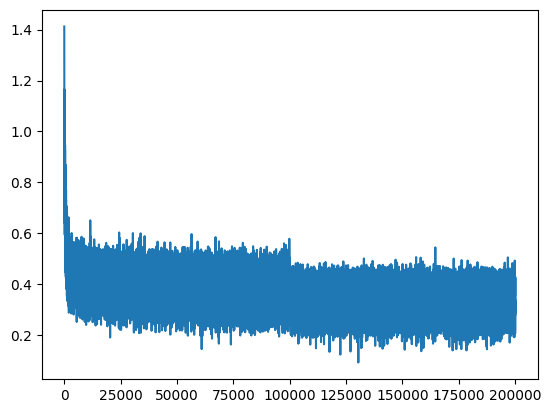

In [18]:
plt.plot(stepi, lossi)


In [25]:
# Evaluate on training set
emb = C[Xtr]
h = torch.tanh(emb.view(-1, block_size * C.shape[1]) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1852, device='cuda:0', grad_fn=<NllLossBackward0>)

In [26]:
# Evaluate on validation set
emb = C[Xdev]
h = torch.tanh(emb.view(-1, block_size * C.shape[1]) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2057, device='cuda:0', grad_fn=<NllLossBackward0>)

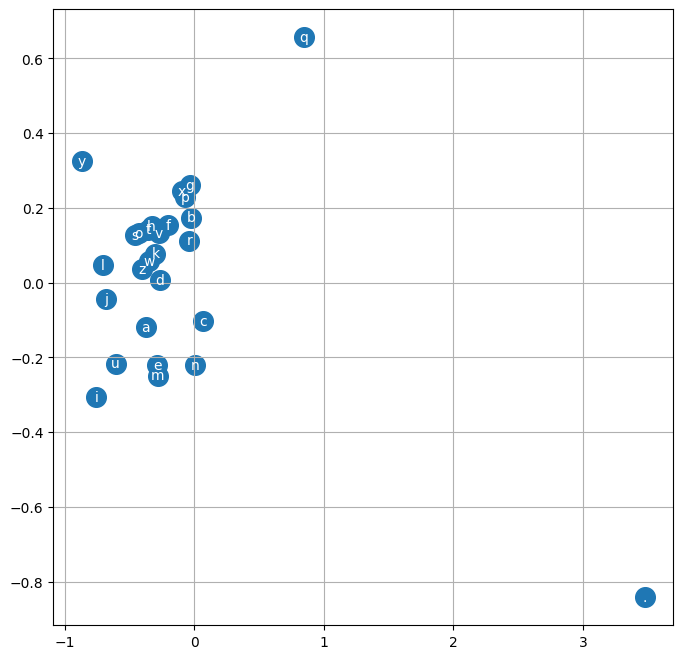

In [21]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
# Move tensors to CPU before plotting
plt.scatter(C[:,0].data.cpu(), C[:,1].data.cpu(), s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [22]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 5, 10])

In [23]:
# sample from the model
g = torch.Generator(device=device).manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # move context to device so it can index into C
      emb = C[torch.tensor([context], device=device)] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      # multinomial happens on the device of 'probs'
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

bike.
sahez.
make.
randar.
hordrine.
breiden.
murai.
emance.
grond.
ewey.
jusi.
methi.
kelioni.
abshttelt.
kedeendyn.
zazerann.
jurlana.
dorga.
driel.
thiten.


### 6. Inference / Sampling
Finally, we sample from the trained model. By providing a starting context of empty characters, the model generates new names by sampling one character at a time based on its predicted probability distribution.

In [27]:
# We must ensure the number of indices matches the first dimension of prob
# Compute prob from the full dataset X first:
emb = C[X]
h = torch.tanh(emb.view(-1, block_size * C.shape[1]) @ W1 + b1)
logits = h @ W2 + b2
prob = F.softmax(logits, dim=1)

# Calculate the negative log likelihood loss
loss = -prob[torch.arange(X.shape[0]), Y].log().mean()
loss

tensor(2.1891, device='cuda:0', grad_fn=<NegBackward0>)

In [ ]:
loss

In [32]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g).to(device)
W1 = torch.randn((block_size * 2, 100), generator=g).to(device)
b1 = torch.randn(100, generator=g).to(device)
W2 = torch.randn((100, 27), generator=g).to(device)
b2 = torch.randn(27, generator=g).to(device)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [29]:
sum(p.nelement() for p in parameters)

3481

In [33]:
for p in parameters:
    p.requires_grad = True

for _ in range(100):
    # Create indices on CPU to index the CPU tensor X
    ix = torch.randint(0, X.shape[0], (32, ))

    # forward pass
    # Index X on CPU, then move the small batch to GPU
    emb = C[X[ix].to(device)] # (32, block_size, 2)
    h = torch.tanh(emb.view(-1, block_size * C.shape[1]) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y[ix].to(device))

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -0.1 * p.grad

print(loss.item())

3.6503872871398926


E01: Tune the hyperparameters of the training to beat my best validation loss of 2.2

E02: I was not careful with the intialization of the network in this video. (1) What is the loss you'd get if the predicted probabilities at initialization were perfectly uniform? What loss do we achieve? (2) Can you tune the initialization to get a starting loss that is much more similar to (1)?

E03: Read the Bengio et al 2003 paper (link above), implement and try any idea from the paper. Did it work?

## E03: Implementing Direct Connections (Bengio et al. 2003)

According to the paper, we can add a direct connection from the input layer (embeddings) to the output layer. The output logits would then be:
`logits = (h @ W2 + b2) + (emb_flattened @ W_direct)`

This means the character embeddings have a direct path to influence the next character prediction linearly.

In [34]:
g = torch.Generator().manual_seed(2147483647)
n_emb = 10
n_hidden = 200

C = torch.randn((27, n_emb), generator=g).to(device)
W1 = torch.randn((block_size * n_emb, n_hidden), generator=g).to(device)
b1 = torch.randn(n_hidden, generator=g).to(device)
W2 = torch.randn((n_hidden, 27), generator=g).to(device)
b2 = torch.randn(27, generator=g).to(device)

# Direct connection weights from input to output
W_direct = torch.randn((block_size * n_emb, 27), generator=g).to(device)

parameters = [C, W1, b1, W2, b2, W_direct]
for p in parameters:
    p.requires_grad = True

print(f"Number of parameters: {sum(p.nelement() for p in parameters)}")

Number of parameters: 17247


In [35]:
for i in range(10000):
    # Minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,), device=device)

    # Forward pass
    emb = C[Xtr[ix]] # (32, block_size, n_emb)
    emb_flat = emb.view(-1, block_size * n_emb)
    h = torch.tanh(emb_flat @ W1 + b1)

    # Logits with direct connection
    logits = (h @ W2 + b2) + (emb_flat @ W_direct)
    loss = F.cross_entropy(logits, Ytr[ix])

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    lr = 0.1 if i < 5000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

print(f"Final batch loss: {loss.item()}")

Final batch loss: 2.446857213973999


### Increasing Block Size to 8

We will now increase the `block_size` to 8 to see if providing more context improves the model's ability to predict the next character.

In [36]:
block_size = 8

# Re-build the datasets with the new block_size
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

# Re-initialize the model with the larger input layer
g = torch.Generator().manual_seed(2147483647)
n_emb = 10
n_hidden = 200

C = torch.randn((27, n_emb), generator=g).to(device)
W1 = torch.randn((block_size * n_emb, n_hidden), generator=g).to(device)
b1 = torch.randn(n_hidden, generator=g).to(device)
W2 = torch.randn((n_hidden, 27), generator=g).to(device)
b2 = torch.randn(27, generator=g).to(device)
W_direct = torch.randn((block_size * n_emb, 27), generator=g).to(device)

parameters = [C, W1, b1, W2, b2, W_direct]
for p in parameters:
    p.requires_grad = True

print(f"New input dimension: {block_size * n_emb}")
print(f"New parameter count: {sum(p.nelement() for p in parameters)}")

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])
New input dimension: 80
New parameter count: 24057


In [41]:
for i in range(20000):
    # Minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,), device=device)

    # Forward pass
    emb = C[Xtr[ix]] # (32, block_size, n_emb)
    emb_flat = emb.view(-1, block_size * n_emb)
    h = torch.tanh(emb_flat @ W1 + b1)

    # Logits with direct connection
    logits = (h @ W2 + b2) + (emb_flat @ W_direct)
    loss = F.cross_entropy(logits, Ytr[ix])

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    lr = 0.1 if i < 10000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 2000 == 0:
        print(f"{i:7d}/20000: {loss.item():.4f}")

print(f"Final training batch loss: {loss.item()}")

      0/20000: 2.2044
   2000/20000: 3.2317
   4000/20000: 2.5316
   6000/20000: 2.6149
   8000/20000: 2.0020
  10000/20000: 2.6619
  12000/20000: 2.5770
  14000/20000: 2.3823
  16000/20000: 2.6497
  18000/20000: 2.0359
Final training batch loss: 2.1381936073303223


In [42]:
# Evaluate performance on validation set
with torch.no_grad():
    emb = C[Xdev]
    emb_flat = emb.view(-1, block_size * n_emb)
    h = torch.tanh(emb_flat @ W1 + b1)
    logits = (h @ W2 + b2) + (emb_flat @ W_direct)
    loss = F.cross_entropy(logits, Ydev)
    print(f'Validation loss: {loss.item()}')

Validation loss: 2.2815170288085938


In [39]:
for i in range(20000):
    # Minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,), device=device)

    # Forward pass
    emb = C[Xtr[ix]] # (32, block_size, n_emb)
    emb_flat = emb.view(-1, block_size * n_emb)
    h = torch.tanh(emb_flat @ W1 + b1)

    # Logits with direct connection
    logits = (h @ W2 + b2) + (emb_flat @ W_direct)
    loss = F.cross_entropy(logits, Ytr[ix])

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    lr = 0.1 if i < 10000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 2000 == 0:
        print(f"{i:7d}/20000: {loss.item():.4f}")

print(f"Final training batch loss: {loss.item()}")

      0/20000: 2.3801
   2000/20000: 2.6822
   4000/20000: 2.7559
   6000/20000: 2.2486
   8000/20000: 2.8575
  10000/20000: 2.6152
  12000/20000: 2.3033
  14000/20000: 2.0931
  16000/20000: 2.3089
  18000/20000: 2.6188
Final training batch loss: 2.1390862464904785


In [40]:
# Evaluate performance on validation set
with torch.no_grad():
    emb = C[Xdev]
    emb_flat = emb.view(-1, block_size * n_emb)
    h = torch.tanh(emb_flat @ W1 + b1)
    logits = (h @ W2 + b2) + (emb_flat @ W_direct)
    loss = F.cross_entropy(logits, Ydev)
    print(f'Validation loss: {loss.item()}')

Validation loss: 2.3005990982055664


In [37]:
for i in range(20000):
    # Minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,), device=device)

    # Forward pass
    emb = C[Xtr[ix]] # (32, block_size, n_emb)
    emb_flat = emb.view(-1, block_size * n_emb)
    h = torch.tanh(emb_flat @ W1 + b1)

    # Logits with direct connection
    logits = (h @ W2 + b2) + (emb_flat @ W_direct)
    loss = F.cross_entropy(logits, Ytr[ix])

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    lr = 0.1 if i < 10000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 2000 == 0:
        print(f"{i:7d}/20000: {loss.item():.4f}")

print(f"Final training batch loss: {loss.item()}")

      0/20000: 33.5973
   2000/20000: 2.8460
   4000/20000: 3.1412
   6000/20000: 2.9973
   8000/20000: 2.3765
  10000/20000: 2.6189
  12000/20000: 2.2040
  14000/20000: 2.4466
  16000/20000: 2.1726
  18000/20000: 2.4130
Final training batch loss: 2.0539255142211914


In [38]:
# Evaluate performance on validation set
with torch.no_grad():
    emb = C[Xdev]
    emb_flat = emb.view(-1, block_size * n_emb)
    h = torch.tanh(emb_flat @ W1 + b1)
    logits = (h @ W2 + b2) + (emb_flat @ W_direct)
    loss = F.cross_entropy(logits, Ydev)
    print(f'Validation loss: {loss.item()}')

Validation loss: 2.3428378105163574
